# 11 — Validation croisée sur UNSW-NB15

## 🎯 Objectif

Tester si la **méthodologie** développée sur CIC-IDS2017 généralise à un autre dataset cyber : **UNSW-NB15** (Moustafa & Slay 2015).

## Question scientifique

> **"Si on applique exactement les mêmes hyperparamètres XGBoost (trouvés via Optuna sur CIC-IDS2017) sur un autre dataset cyber, est-ce qu'on obtient des performances comparables ?"**

## 📋 Plan

1. Chargement UNSW-NB15 (train + test) et fusion
2. **EDA rapide** : structure et différences avec CIC-IDS2017
3. **Preprocessing** : nettoyage + encodage catégoriel + splits
4. **Entraînement XGBoost** avec les hyperparamètres OPTUNA de CIC-IDS2017
5. **Évaluation** sur test set UNSW-NB15
6. **Comparaison rigoureuse** CIC-IDS2017 vs UNSW-NB15
7. Discussion de la généralisation

## ⏱️ Temps estimé

**~10-15 min**.

## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from time import time

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

DATA_RAW = Path('../data/raw/unsw-nb15')
DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')

SEED = 42
np.random.seed(SEED)

print(f'✅ Dossier UNSW-NB15 : {DATA_RAW.resolve()}')
print(f'   Existe : {DATA_RAW.exists()}')

✅ Dossier UNSW-NB15 : C:\Users\natha\Documents\PFE\ids-xai-pfe\data\raw\unsw-nb15
   Existe : True


## 2. Chargement de UNSW-NB15

In [5]:
# Chargement des 2 fichiers
train_path = DATA_RAW / 'UNSW_NB15_training-set.csv'
test_path = DATA_RAW / 'UNSW_NB15_testing-set.csv'

if not train_path.exists() or not test_path.exists():
    print('⚠️  Fichiers manquants ! Vérifie que tu as bien placé :')
    print(f'    - {train_path}')
    print(f'    - {test_path}')
else:
    df_train_orig = pd.read_csv(train_path)
    df_test_orig = pd.read_csv(test_path)
    
    print(f'📊 UNSW_NB15_training-set.csv : {df_train_orig.shape}')
    print(f'📊 UNSW_NB15_testing-set.csv  : {df_test_orig.shape}')
    
    # Concaténation : on va refaire nos propres splits
    df = pd.concat([df_train_orig, df_test_orig], ignore_index=True)
    print(f'\n📊 Dataset complet : {df.shape}')
    print(f'\nColonnes : {list(df.columns)}')

📊 UNSW_NB15_training-set.csv : (175341, 36)
📊 UNSW_NB15_testing-set.csv  : (82332, 36)

📊 Dataset complet : (257673, 36)

Colonnes : ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


In [6]:
# Aperçu
df.head(3)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0,Normal,0


## 3. EDA rapide : structure et classes

Colonne label détectée : attack_cat

Distribution des classes :
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


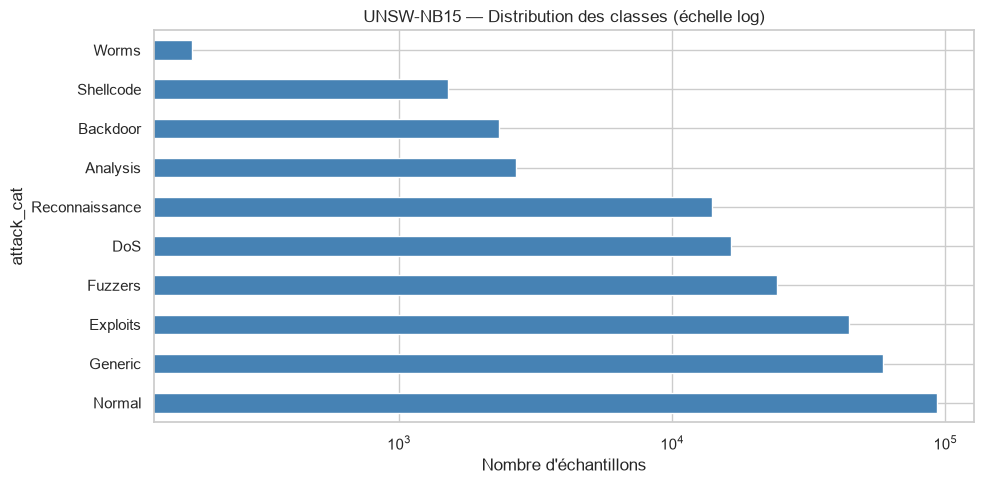

In [7]:
# Distribution des classes (attack_cat)
if 'attack_cat' in df.columns:
    label_col = 'attack_cat'
elif 'Label' in df.columns:
    label_col = 'Label'
else:
    label_col = df.columns[-1]

print(f'Colonne label détectée : {label_col}\n')
print('Distribution des classes :')
print(df[label_col].value_counts())

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
df[label_col].value_counts().plot(kind='barh', color='steelblue', ax=ax)
ax.set_xscale('log')
ax.set_title('UNSW-NB15 — Distribution des classes (échelle log)')
ax.set_xlabel('Nombre d\'échantillons')
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '11_unsw_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Identifier les colonnes
print('Types de colonnes :')
print(df.dtypes.value_counts())
print('\nColonnes catégorielles (object) :')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print('\nNb de NaN par colonne (top 5) :')
print(df.isna().sum().sort_values(ascending=False).head())

Types de colonnes :
int64      21
float64    11
object      4
Name: count, dtype: int64

Colonnes catégorielles (object) :
['proto', 'service', 'state', 'attack_cat']

Nb de NaN par colonne (top 5) :
dur        0
proto      0
service    0
state      0
spkts      0
dtype: int64


## 4. Preprocessing

### 📚 Choix de preprocessing

On reproduit la **même philosophie** que pour CIC-IDS2017 :
1. Supprimer les colonnes inutiles (ID, label binaire `label` redondant avec `attack_cat`)
2. Encoder les features catégorielles (`proto`, `service`, `state`) en one-hot
3. Supprimer NaN / infinis
4. Filtrer les classes trop rares (à effectif < 50)
5. Encoder la cible `attack_cat` en entiers

In [9]:
# Copie de travail
df_clean = df.copy()

# Supprimer 'id' s'il existe
if 'id' in df_clean.columns:
    df_clean = df_clean.drop(columns=['id'])

# Supprimer 'label' (binaire) — on garde attack_cat (multi-classe)
if 'label' in df_clean.columns and label_col == 'attack_cat':
    df_clean = df_clean.drop(columns=['label'])

# Nettoyer les noms de classes (espaces, casse)
df_clean[label_col] = df_clean[label_col].astype(str).str.strip()

# Supprimer NaN et infinis
n_before = len(df_clean)
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()
print(f'Lignes après suppression NaN/inf : {len(df_clean):,} (perdues : {n_before - len(df_clean)})')

# Identifier les colonnes catégorielles vs numériques
cat_features = [c for c in df_clean.select_dtypes(include='object').columns if c != label_col]
num_features = [c for c in df_clean.columns if c not in cat_features + [label_col]]
print(f'\nFeatures catégorielles : {cat_features}')
print(f'Features numériques : {len(num_features)} colonnes')

Lignes après suppression NaN/inf : 257,673 (perdues : 0)

Features catégorielles : ['proto', 'service', 'state']
Features numériques : 31 colonnes


In [10]:
# Filtrer les classes trop rares (effectif < 50)
MIN_CLASS_SIZE = 50
class_counts = df_clean[label_col].value_counts()
keep_classes = class_counts[class_counts >= MIN_CLASS_SIZE].index.tolist()
n_before = len(df_clean)
df_clean = df_clean[df_clean[label_col].isin(keep_classes)].copy()
print(f'Classes conservées ({len(keep_classes)}) : {sorted(keep_classes)}')
print(f'Lignes après filtrage : {len(df_clean):,} (perdues : {n_before - len(df_clean)})')

Classes conservées (10) : ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
Lignes après filtrage : 257,673 (perdues : 0)


In [11]:
# One-hot encoding des features catégorielles
df_encoded = pd.get_dummies(df_clean, columns=cat_features, drop_first=False)
print(f'📊 Shape après one-hot : {df_encoded.shape}')
print(f'   ({df_encoded.shape[1] - len(num_features) - 1} colonnes dummy ajoutées)')

# Encoder la cible
le = LabelEncoder()
y_unsw = le.fit_transform(df_encoded[label_col])
class_names_unsw = list(le.classes_)
num_classes_unsw = len(class_names_unsw)

label_mapping_unsw = {int(i): c for i, c in enumerate(class_names_unsw)}
print(f'\n🏷️  Mapping classes UNSW :')
for k, v in label_mapping_unsw.items():
    n = (y_unsw == k).sum()
    print(f'   {k} : {v:15s} ({n:>7,} exemples)')

# Features finales
feature_cols_unsw = [c for c in df_encoded.columns if c != label_col]
X_unsw = df_encoded[feature_cols_unsw].values.astype(np.float32)
print(f'\n📊 X final : {X_unsw.shape}')
print(f'   y final : {y_unsw.shape}')

📊 Shape après one-hot : (257673, 189)
   (157 colonnes dummy ajoutées)

🏷️  Mapping classes UNSW :
   0 : Analysis        (  2,677 exemples)
   1 : Backdoor        (  2,329 exemples)
   2 : DoS             ( 16,353 exemples)
   3 : Exploits        ( 44,525 exemples)
   4 : Fuzzers         ( 24,246 exemples)
   5 : Generic         ( 58,871 exemples)
   6 : Normal          ( 93,000 exemples)
   7 : Reconnaissance  ( 13,987 exemples)
   8 : Shellcode       (  1,511 exemples)
   9 : Worms           (    174 exemples)

📊 X final : (257673, 188)
   y final : (257673,)


## 5. Splits stratifiés

Même proportion 70/15/15 que pour CIC-IDS2017 — méthodologie identique.

In [12]:
X_trainval_u, X_test_u, y_trainval_u, y_test_u = train_test_split(
    X_unsw, y_unsw, test_size=0.15, stratify=y_unsw, random_state=SEED
)
X_train_u, X_val_u, y_train_u, y_val_u = train_test_split(
    X_trainval_u, y_trainval_u, test_size=0.15/0.85,
    stratify=y_trainval_u, random_state=SEED,
)

print(f'Train : {X_train_u.shape[0]:>10,}')
print(f'Val   : {X_val_u.shape[0]:>10,}')
print(f'Test  : {X_test_u.shape[0]:>10,}')

# Sample weights pour le déséquilibre
sample_weights_u = compute_sample_weight('balanced', y_train_u)
print(f'\nSample weights range : [{sample_weights_u.min():.4f}, {sample_weights_u.max():.4f}]')

Train :    180,371
Val   :     38,651
Test  :     38,651

Sample weights range : [0.2771, 147.8451]


## 6. Entraînement XGBoost avec les hyperparamètres CIC-IDS2017

### 📚 La clé méthodologique

**On ne refait PAS d'Optuna.** On utilise **exactement les mêmes hyperparamètres** que ceux trouvés via Optuna sur CIC-IDS2017. C'est ce qui permet de tester la généralisation de la **méthodologie** (pas seulement du modèle exact).

Si ces hyperparamètres marchent aussi bien sur UNSW-NB15, c'est qu'ils capturent quelque chose de **général** sur le problème de la détection d'intrusion.

In [13]:
# Chargement des hyperparamètres Optuna trouvés sur CIC-IDS2017
with open(RESULTS_METRICS / 'xgb_best_params.json') as f:
    best_params_cic = json.load(f)

print('🎯 Hyperparamètres XGBoost (issus d\'Optuna sur CIC-IDS2017) :')
for k, v in best_params_cic.items():
    print(f'   {k} = {v}')

# Adapter pour UNSW (nb classes différent)
params_unsw = {
    **best_params_cic,
    'objective': 'multi:softprob',
    'num_class': num_classes_unsw,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': SEED,
}
params_unsw.pop('class_weight', None)   # géré par sample_weight

print(f'\n🚀 Entraînement XGBoost sur UNSW-NB15...')
t0 = time()
xgb_unsw = xgb.XGBClassifier(**params_unsw)
xgb_unsw.fit(
    X_train_u, y_train_u,
    sample_weight=sample_weights_u,
    eval_set=[(X_val_u, y_val_u)],
    verbose=False,
)
elapsed = time() - t0
print(f'✅ Entraînement terminé en {elapsed:.1f}s')

🎯 Hyperparamètres XGBoost (issus d'Optuna sur CIC-IDS2017) :
   n_estimators = 367
   max_depth = 11
   learning_rate = 0.08277688592913943
   subsample = 0.9438245048353373
   colsample_bytree = 0.8419513725750356
   min_child_weight = 2
   gamma = 0.10783457417904042
   reg_alpha = 0.1169252904972853
   reg_lambda = 0.7546010826027338

🚀 Entraînement XGBoost sur UNSW-NB15...
✅ Entraînement terminé en 60.2s


## 7. Évaluation sur test set UNSW-NB15

In [14]:
# Prédictions sur test
t0 = time()
y_test_pred_u = xgb_unsw.predict(X_test_u)
unsw_inference_time = time() - t0
unsw_throughput = len(y_test_u) / unsw_inference_time

# Métriques
unsw_acc = accuracy_score(y_test_u, y_test_pred_u)
unsw_f1_macro = f1_score(y_test_u, y_test_pred_u, average='macro')
unsw_f1_weighted = f1_score(y_test_u, y_test_pred_u, average='weighted')

print(f'⏱️  Inférence : {unsw_inference_time:.2f}s ({unsw_throughput:,.0f} flows/s)')
print(f'\n📊 XGBoost sur UNSW-NB15 — Test set')
print(f'   Accuracy     : {unsw_acc:.4f}')
print(f'   F1 macro     : {unsw_f1_macro:.4f}')
print(f'   F1 pondéré   : {unsw_f1_weighted:.4f}')

⏱️  Inférence : 0.45s (85,705 flows/s)

📊 XGBoost sur UNSW-NB15 — Test set
   Accuracy     : 0.7666
   F1 macro     : 0.5647
   F1 pondéré   : 0.7962


In [15]:
print('📋 Rapport par classe sur UNSW-NB15 :\n')
unsw_report = classification_report(
    y_test_u, y_test_pred_u,
    target_names=class_names_unsw, digits=4,
)
print(unsw_report)

unsw_report_dict = classification_report(
    y_test_u, y_test_pred_u,
    target_names=class_names_unsw, output_dict=True,
)
with open(RESULTS_METRICS / 'xgb_unsw_test_report.json', 'w') as f:
    json.dump(unsw_report_dict, f, indent=2)

📋 Rapport par classe sur UNSW-NB15 :

                precision    recall  f1-score   support

      Analysis     0.0460    0.2045    0.0751       401
      Backdoor     0.0433    0.2464    0.0736       349
           DoS     0.3590    0.3587    0.3589      2453
      Exploits     0.8582    0.5347    0.6589      6679
       Fuzzers     0.5577    0.7575    0.6424      3637
       Generic     0.9967    0.9792    0.9878      8831
        Normal     0.9595    0.8396    0.8956     13950
Reconnaissance     0.8528    0.8093    0.8305      2098
     Shellcode     0.4363    0.7841    0.5606       227
         Worms     0.4444    0.7692    0.5634        26

      accuracy                         0.7666     38651
     macro avg     0.5554    0.6283    0.5647     38651
  weighted avg     0.8476    0.7666    0.7962     38651



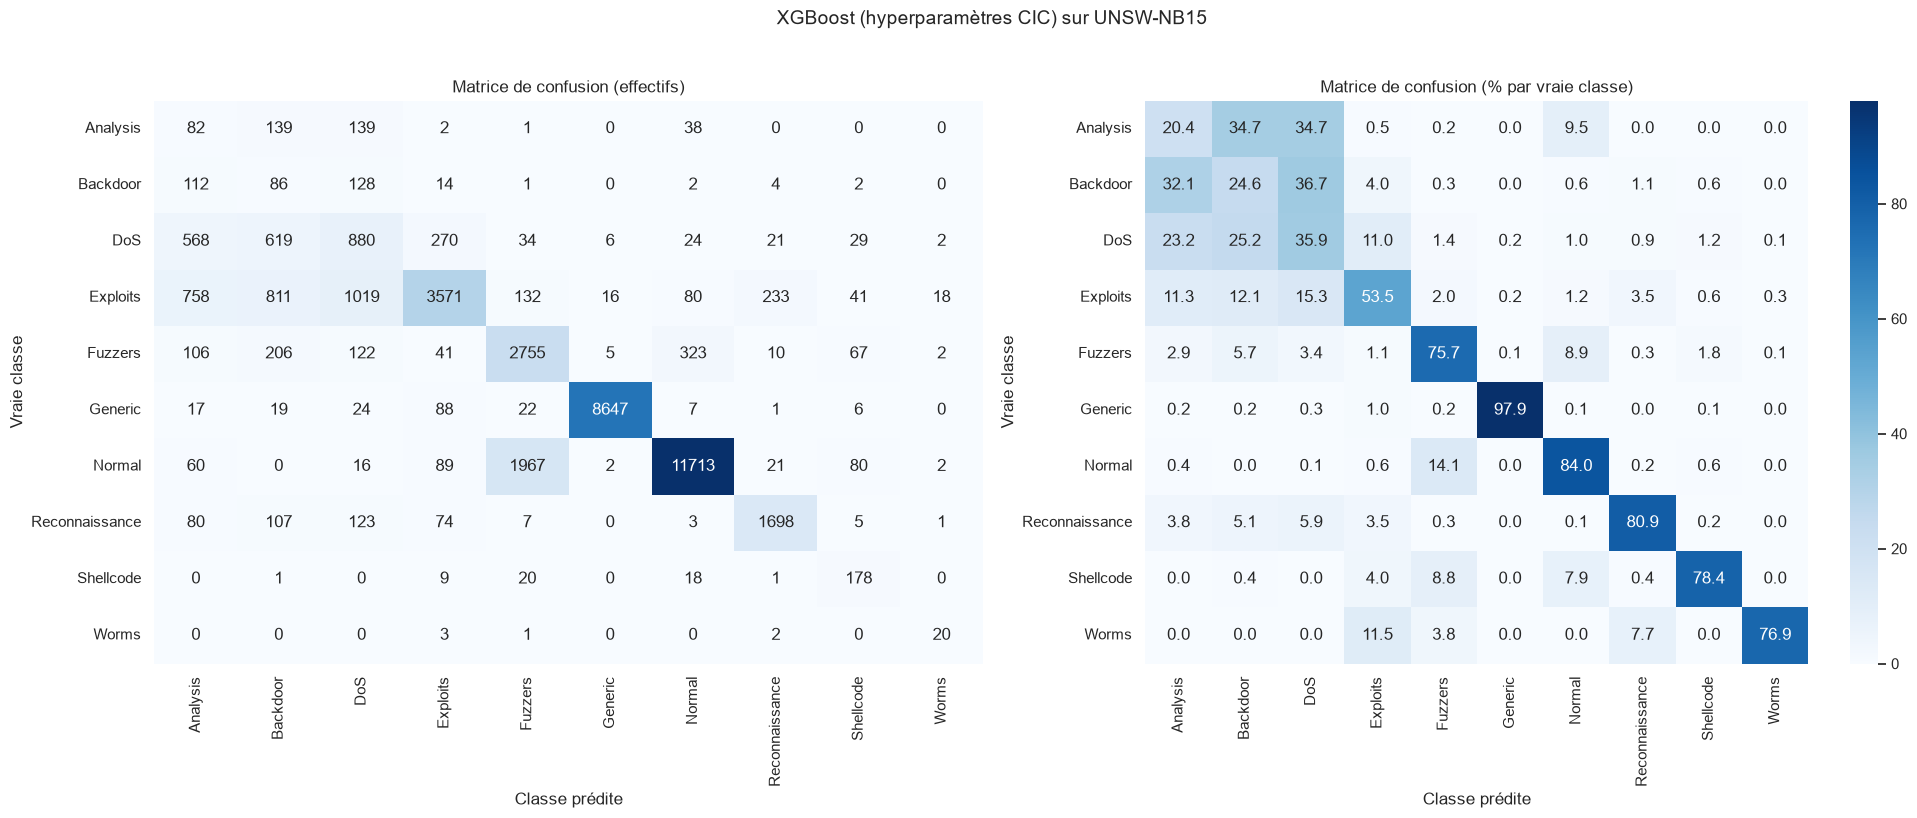

In [16]:
# Matrice de confusion UNSW
cm = confusion_matrix(y_test_u, y_test_pred_u)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names_unsw, yticklabels=class_names_unsw,
    ax=axes[0], cbar=False,
)
axes[0].set_title('Matrice de confusion (effectifs)')
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Vraie classe')

sns.heatmap(
    cm_norm, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=class_names_unsw, yticklabels=class_names_unsw,
    ax=axes[1], cbar=True,
)
axes[1].set_title('Matrice de confusion (% par vraie classe)')
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Vraie classe')

plt.suptitle('XGBoost (hyperparamètres CIC) sur UNSW-NB15', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '11_unsw_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparaison rigoureuse CIC-IDS2017 vs UNSW-NB15

**Le moment de vérité** : la méthodologie XGBoost+Optuna(CIC) se généralise-t-elle ?

In [17]:
# Recharger les résultats CIC-IDS2017
with open(RESULTS_METRICS / 'xgb_test_report.json') as f:
    cic_report = json.load(f)

# Tableau comparatif
comparison = pd.DataFrame({
    'Dataset': ['CIC-IDS2017', 'UNSW-NB15'],
    'Accuracy': [cic_report['accuracy'], unsw_acc],
    'F1 macro': [cic_report['macro avg']['f1-score'], unsw_f1_macro],
    'F1 pondéré': [cic_report['weighted avg']['f1-score'], unsw_f1_weighted],
    'Nb classes': [7, num_classes_unsw],
    'Taille test': [int(cic_report['BENIGN']['support']) + sum(int(cic_report[c]['support']) for c in cic_report if c not in ['accuracy', 'macro avg', 'weighted avg', 'BENIGN']), len(y_test_u)],
})

print('=' * 80)
print(f'  COMPARAISON CIC-IDS2017 vs UNSW-NB15 (test set)')
print('=' * 80)
print(comparison.to_string(index=False))
print('=' * 80)

comparison.to_csv(RESULTS_METRICS / 'cic_vs_unsw_summary.csv', index=False)

  COMPARAISON CIC-IDS2017 vs UNSW-NB15 (test set)
    Dataset  Accuracy  F1 macro  F1 pondéré  Nb classes  Taille test
CIC-IDS2017  0.999039  0.968888    0.999073           7       377682
  UNSW-NB15  0.766604  0.564678    0.796203          10        38651


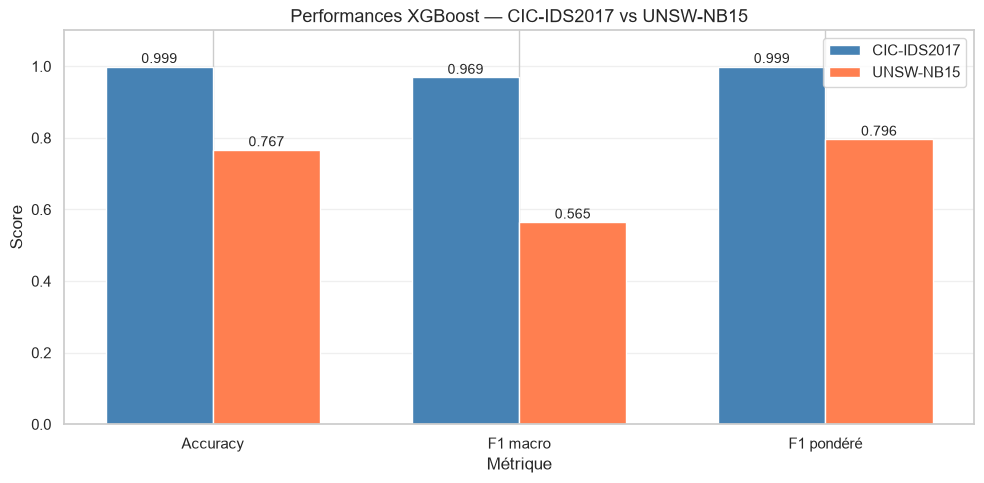

In [18]:
# Graphique comparatif
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'F1 macro', 'F1 pondéré']
cic_values = [cic_report['accuracy'], cic_report['macro avg']['f1-score'], cic_report['weighted avg']['f1-score']]
unsw_values = [unsw_acc, unsw_f1_macro, unsw_f1_weighted]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, cic_values, width, label='CIC-IDS2017', color='steelblue')
bars2 = ax.bar(x + width/2, unsw_values, width, label='UNSW-NB15', color='coral')

ax.set_xlabel('Métrique')
ax.set_ylabel('Score')
ax.set_title('Performances XGBoost — CIC-IDS2017 vs UNSW-NB15', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

for bars, vals in [(bars1, cic_values), (bars2, unsw_values)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '11_cic_vs_unsw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Sauvegarder le modèle UNSW
model_path = RESULTS_MODELS / 'xgb_unsw.joblib'
joblib.dump(xgb_unsw, model_path, compress=3)
print(f'✅ Modèle UNSW sauvegardé : {model_path}')

✅ Modèle UNSW sauvegardé : ..\results\models\xgb_unsw.joblib


## 🎉 Récapitulatif

Tu viens de produire **la première validation croisée méthodologique** de ton projet.

### Outputs produits

**Figures :**
- `11_unsw_class_distribution.png`
- `11_unsw_confusion_matrix.png`
- `11_cic_vs_unsw_comparison.png`

**Données :**
- `xgb_unsw_test_report.json` : métriques détaillées UNSW
- `cic_vs_unsw_summary.csv` : tableau comparatif
- `results/models/xgb_unsw.joblib` : le modèle entraîné sur UNSW

### Prochaine étape (notebook 12)

**Dashboard Streamlit** : un mini-démonstrateur visuel où on charge ton modèle XGBoost + SHAP, et on visualise interactivement des alertes expliquées. **Ça impressionne énormément en soutenance.**